In [ ]:
!pip install shap==0.46.0

In [ ]:
!pip install xgboost==1.6.2

In [ ]:
from google.colab import drive
drive.mount('/drive', force_remount=True)
plot_path1 = ''
file_path = ''
plot_path = ''
file_path1 = ''

Mounted at /drive


In [ ]:
import pandas as pd
import numpy as np

import xgboost as xgb
from sklearn.model_selection import KFold, train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_rel, wilcoxon
import warnings
import seaborn as sns

# Ignore future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('mode.chained_assignment', None)

file_path = "maize_dataset.csv"


# Function to safely load the CSV file
def load_csv(file_path):
    try:
        return pd.read_csv(file_path,low_memory=False)
    except FileNotFoundError:
        print(f"Error: File not found at path {file_path}")
        return None
    except pd.errors.ParserError:
        print("Error: Failed to parse CSV file.")
        return None

# Load the CSV file
data = load_csv(file_path)
if data is None:
    exit()

# Ensure data has expected structure
if data.shape[1] < 2:
    print("Error: CSV file does not have enough columns.")
    exit()
# classification into different environments based on temperature/ rainfall
data = data[~(data['Min Temperature [C]'].isna() & data['Max Temperature [C]'].isna())]
data1 = data
data = data[~(data['Min Rainfall [mm]'].isna() & data['Max Rainfall [mm]'].isna() & data['Median Rainfall [mm]'].isna())]
data.loc[:, 'Median Temperature'] = data[['Min Temperature [C]', 'Max Temperature [C]']].median(axis=1)
overall_median_temp = data['Median Temperature'].median()
# print(f"Overall median temperature: {overall_median_temp}")
def classify_climate(temp):
    if temp < overall_median_temp:  # Below the overall median
        return 'Cold'
    else:  # Equal to or above the overall median
        return 'Hot'
data['Climate Category'] = data['Median Temperature'].apply(classify_climate)
rainfall_median = data['Max Rainfall [mm]'].median()
data['Rainfall Category'] = data['Max Rainfall [mm]'].apply(
    lambda x: 'wet' if x > rainfall_median else 'dry'
)
# Filter the data based on the categories
hot_wet = data[(data['Climate Category'] == 'Hot') & (data['Rainfall Category'] == 'wet')]
hot_dry = data[(data['Climate Category'] == 'Hot') & (data['Rainfall Category'] == 'dry')]
cold_wet = data[(data['Climate Category'] == 'Cold') & (data['Rainfall Category'] == 'wet')]
cold_dry = data[(data['Climate Category'] == 'Cold') & (data['Rainfall Category'] == 'dry')]

# Function to evaluate the model
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mean_true = np.mean(y_true)
    rmae = mae / mean_true if mean_true != 0 else np.nan
    rrms = rmse / mean_true if mean_true != 0 else np.nan
    return rmae, rrms, r2

# Extract relevant data columns
try:
    yield_data = data['Grain Yield [bu/A]']  # Yield data
    print('Yield data shape: ',yield_data.shape)
    # Correctly passing column names as a list
    env_columns = ['Plot Length Field', 'Alley Length', 'Row Spacing', 'Plot Area', 'Rows/Plot', 'Packet/Plot',
                   'Kernels/Packet', '# Seed', 'Min Temperature [C]', 'Max Temperature [C]',
                   'Min Dew Point [C]', 'Max Dew Point [C]', 'Median Dew Point [C]',
                   'Min Rainfall [mm]', 'Max Rainfall [mm]', 'Median Rainfall [mm]',
                   'Min Soil Moisture [%VWC]', 'Max Soil Moisture [%VWC]',
                   'Median Soil Moisture [%VWC]', 'E Depth', '1:1 Soil pH',
                   'WDRF Buffer pH', '1:1 S Salts mmho/cm', 'Texture No',
                   'Organic Matter LOI %', 'Nitrate-N ppm N', 'lbs N/A',
                   'Potassium ppm K', 'Sulfate-S ppm S', 'Calcium ppm Ca',
                   'Magnesium ppm Mg', 'Sodium ppm Na',
                   'CEC/Sum of Cations me/100g', '%H Sat', '%K Sat',
                   '%Ca Sat', '%Mg Sat', '%Na Sat', 'Mehlich P-III ppm P',
                   '% Sand', '% Silt', '% Clay']

    env_data = data[env_columns].copy()  # Environmental data
    env_data['Seeds per plot area'] = env_data['# Seed'] / env_data['Plot Area']
    env_data.drop(['Kernels/Packet','Plot Area','# Seed','Packet/Plot'],axis=1,inplace=True)
    print('Env data shape', env_data.shape)
    # Gene data (all SNP columns)
    snp_columns = ['S1_566409_C_T', 'S1_565670_G_C', 'S1_697516_G_A', 'S1_698914_C_T', 'S1_699303_T_G',
                   'S1_699335_T_+', 'S1_699481_G_A', 'S1_699332_G_C', 'S1_697867_T_G', 'S1_691383_G_T',
                   'S1_697694_G_T', 'S1_564761_C_A', 'S1_564790_A_G', 'S1_559641_C_T',
                   'S1_566879_T_A', 'S1_566919_C_T', 'S1_215128_G_A', 'S1_698821_C_T',
                   'S1_699017_A_G', 'S1_698922_A_G', 'S1_697607_C_T', 'S1_699711_A_T',
                   'S1_696567_T_C', 'S1_698913_A_C', 'S1_692642_A_T;+', 'S1_698973_A_G',
                   'S1_699326_T_C', 'S1_698301_C_T', 'S1_690647_C_T', 'S1_689689_A_C',
                   'S1_694176_G_A', 'S1_692383_C_A;G', 'S1_210821_C_T', 'S1_693381_C_T',
                   'S1_212870_T_C', 'S1_699369_C_T', 'S1_213678_T_C', 'S1_697614_G_A',
                   'S1_567708_G_A', 'S1_563835_G_A', 'S1_699748_C_T', 'S1_691226_C_T',
                   'S1_699313_T_G', 'S1_698820_C_T', 'S1_698707_C_T', 'S1_562469_G_A',
                   'S1_691401_A_T', 'S1_561726_C_T', 'S1_699746_T_A', 'S1_566425_C_T',
                   'S1_561528_T_C', 'S1_561748_G_T', 'S1_693685_A_T', 'S1_567553_T_G',
                   'S1_699750_G_T', 'S1_214095_G_A', 'S1_695981_A_G', 'S1_698550_G_A',
                   'S1_565020_C_T', 'S1_699073_G_A', 'S1_564749_G_A', 'S1_561583_T_C',
                   'S1_565117_A_C', 'S1_699790_G_A', 'S1_689700_A_G', 'S1_699290_G_A',
                   'S1_699092_C_T', 'S1_697687_C_T', 'S1_215289_G_A', 'S1_698982_T_A',
                   'S1_695385_C_T', 'S1_693560_C_T', 'S1_699014_T_G', 'S1_564313_T_C',
                   'S1_693669_C_T', 'S1_697695_T_C', 'S1_697044_A_T', 'S1_696690_C_T',
                   'S1_691446_C_T', 'S1_698882_T_A', 'S1_699530_C_T', 'S1_697966_G_A',
                   'S1_698444_C_T', 'S1_698724_G_A', 'S1_697688_C_G', 'S1_210820_A_T',
                   'S1_698365_C_T', 'S1_699015_A_G', 'S1_698909_G_A', 'S1_698390_A_G',
                   'S1_699818_C_T', 'S1_698302_C_T;+', 'S1_697685_T_G', 'S1_693297_A_G',
                   'S1_692904_C_T', 'S1_697037_C_T', 'S1_689409_T_A', 'S1_698906_A_G',
                   'S1_697590_G_A', 'S1_698368_C_T']  # Adjust to match the index for SNP data

    gene_data = data[snp_columns]  # Extract gene data
    print("snp columns",len(snp_columns))
    print('Gene data shape',gene_data.shape)
except KeyError as e:
    print(f"Error: {e} not found in data.")
    exit()

# Convert yield data to numeric
yield_data = pd.to_numeric(yield_data, errors='coerce').astype(float).round(2)

# Define the number of boosting rounds for XGBoost
num_boost_round = 100

# Initialize lists to store results
results_with_gene_data = []
results_without_gene_data = []

# XGBoost hyperparameters
params = {
    'eta': 0.1,  # Learning rate
    'max_depth': 6,  # Maximum tree depth
    'min_child_weight': 1,  # Minimum sum of instance weight needed in a child
    'subsample': 0.8,  # Fraction of samples used for each tree
    'colsample_bytree': 0.8,  # Fraction of features used for each tree
    'objective': 'reg:squarederror',  # Objective function for regression
    'eval_metric': 'rmse' # Evaluation metric
}

# train and test data preparation
#train_data = cold_dry
#test_data = cold_dry

### 80-20 split
target = 'Grain Yield [bu/A]'
cold_dry = cold_dry.dropna(subset=[target])

X = cold_dry.drop(target, axis=1)
y = cold_dry[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.20,random_state=42)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

train_data = cold_dry.loc[X_train.index].copy()
test_data = cold_dry.loc[X_test.index].copy()

# train data
yield_train = train_data['Grain Yield [bu/A]']
env_train = train_data[env_columns].copy()
env_train['Seeds per plot area'] = env_train['# Seed'] / env_train['Plot Area']
env_train.drop(['Kernels/Packet','Plot Area','# Seed','Packet/Plot'],axis=1,inplace=True)
gene_train = train_data[snp_columns]
# test data
yield_test = test_data['Grain Yield [bu/A]']
env_test = test_data[env_columns].copy()
env_test['Seeds per plot area'] = env_test['# Seed'] / env_test['Plot Area']
env_test.drop(['Kernels/Packet','Plot Area','# Seed','Packet/Plot'],axis=1,inplace=True)
gene_test = test_data[snp_columns]


# Reset indices to ensure no index mismatch
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# Handle missing values (if any)
yield_train = pd.to_numeric(yield_train, errors='coerce')
yield_test = pd.to_numeric(yield_test, errors='coerce')

# Remove NaN values if present in the yield data
if yield_train.isna().sum() > 0:
    print("Warning: NaN values found in yield_train. They will be removed.")
    valid_train_indices = ~yield_train.isna()
    yield_train = yield_train[valid_train_indices]
    env_train = env_train[valid_train_indices]
    gene_train = gene_train[valid_train_indices]

if yield_test.isna().sum() > 0:
    print("Warning: NaN values found in yield_test. They will be removed.")
    valid_test_indices = ~yield_test.isna()
    yield_test = yield_test[valid_test_indices]
    env_test = env_test[valid_test_indices]
    gene_test = gene_test[valid_test_indices]

# Combine environmental and genetic data for training and testing
combined_train_data = pd.concat([env_train.reset_index(drop=True), gene_train.reset_index(drop=True)], axis=1)
combined_test_data = pd.concat([env_test.reset_index(drop=True), gene_test.reset_index(drop=True)], axis=1)

combined_train_data.columns = combined_train_data.columns.str.replace(r'[\[\]<]', '', regex=True)
env_train.columns = env_train.columns.str.replace(r'[\[\]<]', '', regex=True)

# Prepare the feature names
feature_names_with_gene = [str(name) for name in combined_train_data.columns]
feature_names_without_gene = [str(name) for name in env_train.columns]

# Create DMatrix for training and validation data
dtrain_with_gene = xgb.DMatrix(combined_train_data, label=yield_train, feature_names=feature_names_with_gene)
dval_with_gene = xgb.DMatrix(combined_test_data, label=yield_test, feature_names=feature_names_with_gene)

# Create DMatrix for training and validation data without gene data
dtrain_without_gene = xgb.DMatrix(env_train, label=yield_train, feature_names=feature_names_without_gene)
dval_without_gene = xgb.DMatrix(env_test, label=yield_test, feature_names=feature_names_without_gene)

# Train model with gene data
model_with_gene = xgb.train(params, dtrain_with_gene, num_boost_round=num_boost_round,
                            evals=[(dtrain_with_gene, 'train')],
                            verbose_eval=100)
y_pred_with_gene = model_with_gene.predict(dval_with_gene)
results_with_gene_data.append(evaluate_model(yield_test, y_pred_with_gene))

# Train model without gene data
model_without_gene = xgb.train(params, dtrain_without_gene, num_boost_round=num_boost_round,
                               evals=[(dtrain_without_gene, 'train')],
                               verbose_eval=100)
y_pred_without_gene = model_without_gene.predict(dval_without_gene)
results_without_gene_data.append(evaluate_model(yield_test, y_pred_without_gene))

# Print the evaluation results
print("\nResults with Gene Data:")
print(results_with_gene_data)

print("\nResults without Gene Data:")
print(results_without_gene_data)


Yield data shape:  (9202,)
Env data shape (9202, 39)
snp columns 100
Gene data shape (9202, 100)
Train set size: 2551
Test set size: 638
[0]	train-rmse:136.74908
[99]	train-rmse:29.59253
[0]	train-rmse:136.75426
[99]	train-rmse:30.58984
Results with Gene Data:
[(np.float64(0.14958899015348515), np.float64(0.19589799097075786), 0.2036228404253998)]

Results without Gene Data:
[(np.float64(0.15206968073513605), np.float64(0.19912812056711768), 0.17714365734451243)]


In [ ]:
import os
plot_path = "./plots"

train_data.name = 'cold_dry'
test_data.name = 'cold_dry'
save_dir = f"{plot_path}/2019-train-{train_data.name}/test-{test_data.name}"
os.makedirs(save_dir, exist_ok=True)
processed_train_name = ','.join([word.capitalize() for word in train_data.name.split('_')])
processed_test_name = ','.join([word.capitalize() for word in test_data.name.split('_')])

In [ ]:
# Create explainer for model with gene data
explainer_with_gene = shap.TreeExplainer(model_with_gene)
shap_values_with_gene = explainer_with_gene(dval_with_gene)

# Create explainer for model without gene data
explainer_without_gene = shap.TreeExplainer(model_without_gene)
shap_values_without_gene = explainer_without_gene(dval_without_gene)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:299: UserWarning: `shap.Explanation` does not support `xgboost.DMatrix` objects for xgboost < 1.7, so the `data` attribute of the `Explanation` object will be set to None. If you require the `data` attribute (e.g. using `shap.plots`), then either update your xgboost to >=1.7.0 or explicitly set `Explanation.data = X`, where `X` is a numpy or scipy array.
  warnings.warn(wmsg)


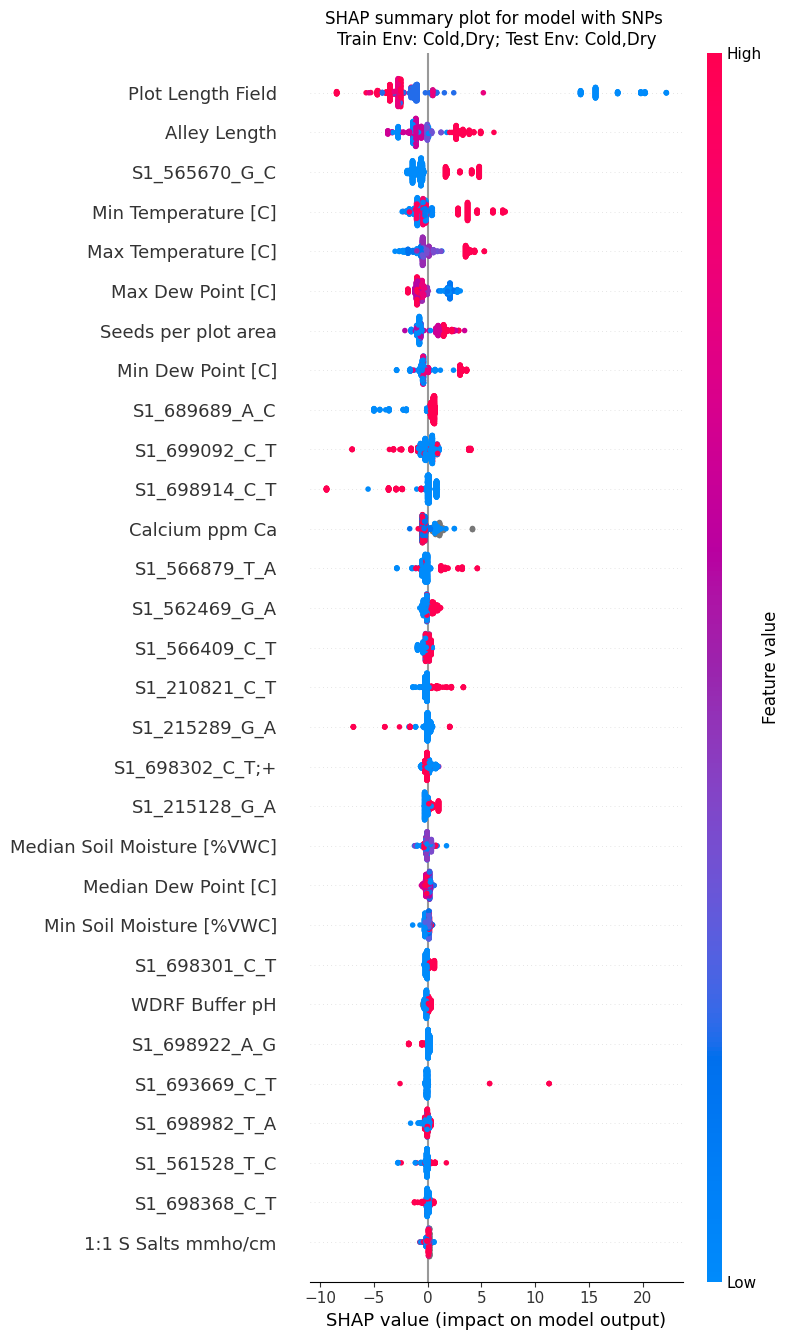

In [ ]:
# Summary plot for model with gene data
plt.clf()
shap.summary_plot(shap_values_with_gene, combined_test_data, show=False,max_display=30)
plt.title(f"SHAP summary plot for model with SNPs \nTrain Env: {processed_train_name}; Test Env: {processed_test_name}")
plt.tight_layout()
plt.savefig(f"{save_dir}/summary_gene.png")

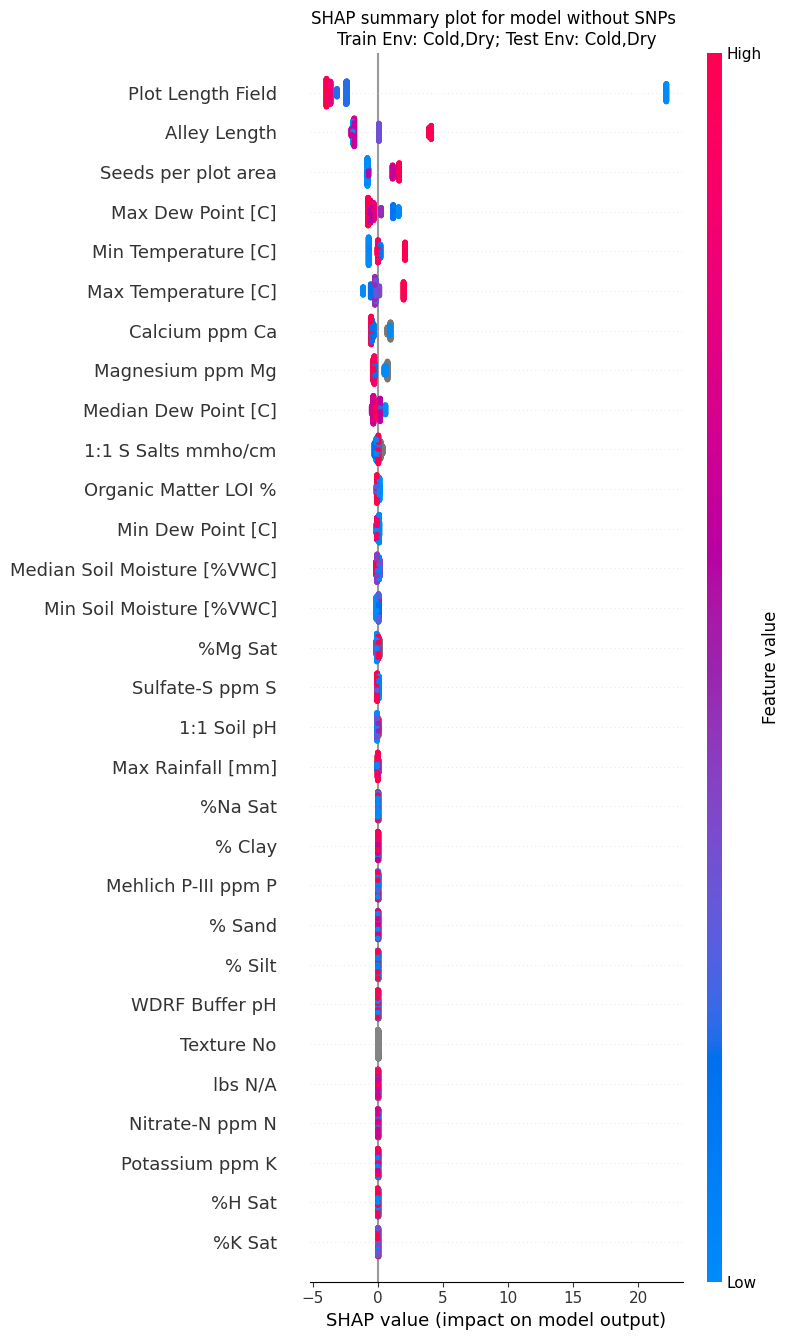

In [ ]:
plt.clf()
shap.summary_plot(shap_values_without_gene, env_test,max_display=30,show=False)
plt.title(f"SHAP summary plot for model without SNPs \nTrain Env: {processed_train_name}; Test Env: {processed_test_name}")
plt.tight_layout()
plt.savefig(f"{save_dir}/summary_without_gene.png")

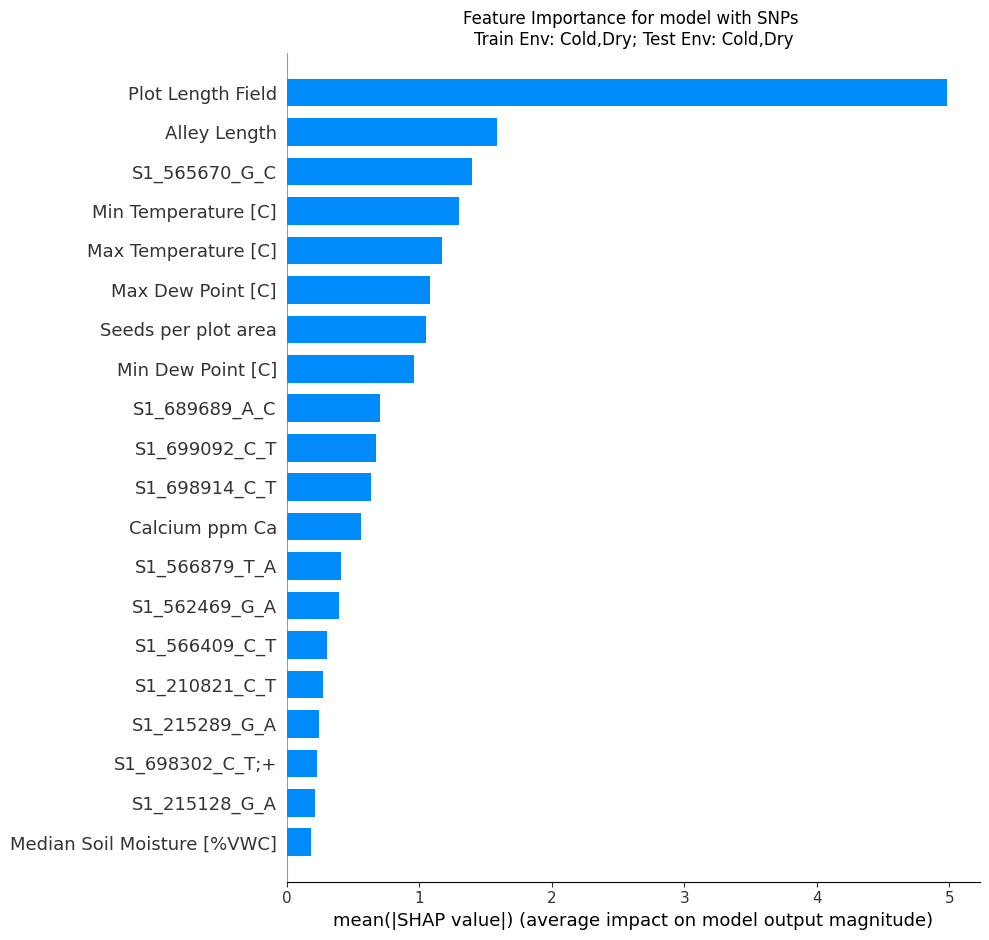

In [ ]:
# bar plot for feature importance
plt.clf()
shap.summary_plot(shap_values_with_gene, combined_test_data, plot_type="bar",show=False,plot_size=[10,9.5])
plt.title(f"Feature Importance for model with SNPs \nTrain Env: {processed_train_name}; Test Env: {processed_test_name}")
# print(f'Size: {plt.gcf().get_size_inches()}') - get plot size (original: [8,9.5])
plt.tight_layout()
plt.savefig(f"{save_dir}/bar_gene.png")

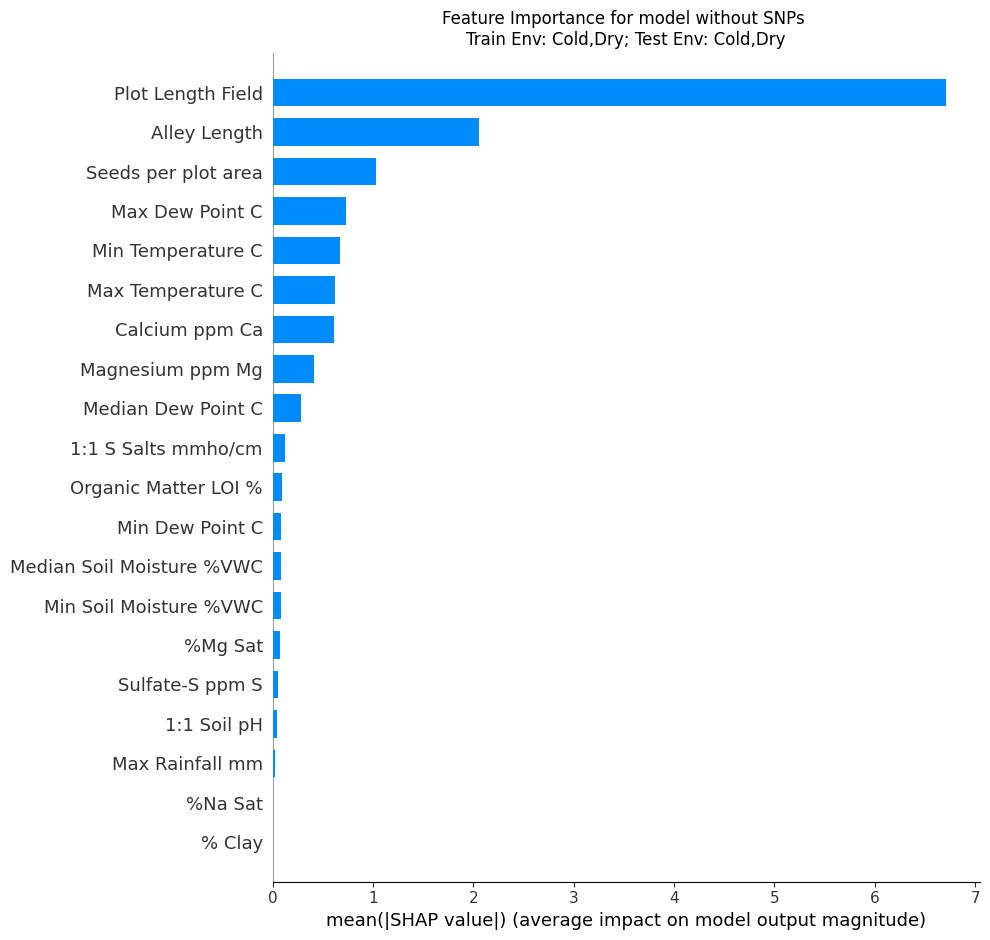

In [ ]:
# bar plot for feature importance
plt.clf()
shap.summary_plot(shap_values_without_gene, env_train, plot_type="bar",show=False,plot_size=[10,9.5])
plt.title(f"Feature Importance for model without SNPs \nTrain Env: {processed_train_name}; Test Env: {processed_test_name}")
plt.tight_layout()
plt.savefig(f"{save_dir}/bar_no_gene.png")

Results with Gene Data:


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-4159139945.py:38: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat_mae, p_value_mae = ttest_rel(mae_with_gene, mae_without_gene)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1006: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return fun(*args, **kwargs)
/tmp/ipython-input-4159139945.py:46: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
 

IndexError: invalid index to scalar variable.

<Figure size 640x480 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

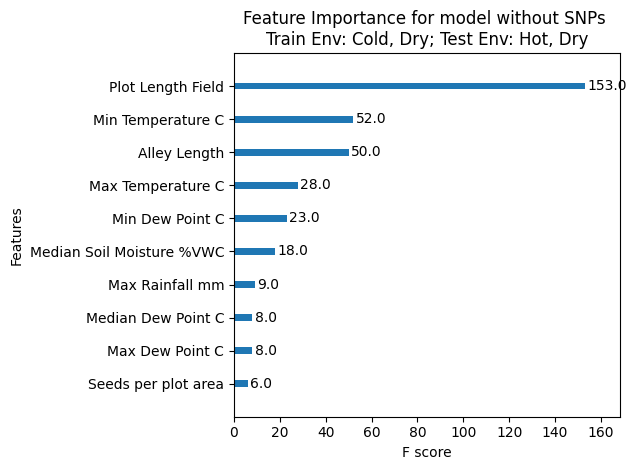

In [ ]:
from xgboost import plot_importance

# feature importance with gene
plt.clf()
plt.figure(figsize=(10, 6))
plot_importance(model_with_gene, importance_type='weight', max_num_features=10,grid=False)
plt.title(f"Feature Importance for model with SNPs \nTrain Env: {processed_train_name}; Test Env: {processed_test_name}")
plt.xlabel('F score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig(f"{save_dir}/feature_importance_with_gene.png")
from xgboost import plot_importance
# feature importance without gene
plt.clf()
plt.figure(figsize=(10, 6))
plot_importance(model_without_gene, importance_type='weight', max_num_features=10,grid=False)
plt.title(f"Feature Importance for model without SNPs \nTrain Env: {processed_train_name}; Test Env: {processed_test_name}")
plt.xlabel('F score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig(f"{save_dir}/feature_importance_without_gene.png")
# Calculate average results
avg_results_with_gene_data = np.mean(results_with_gene_data, axis=0)
avg_results_without_gene_data = np.mean(results_without_gene_data, axis=0)

# Extract metrics for statistical testing
mae_with_gene = np.array([result[0] for result in results_with_gene_data])
mae_without_gene = np.array([result[0] for result in results_without_gene_data])

rmse_with_gene = np.array([result[1] for result in results_with_gene_data])
rmse_without_gene = np.array([result[1] for result in results_without_gene_data])

r2_with_gene = np.array([result[2] for result in results_with_gene_data])
r2_without_gene = np.array([result[2] for result in results_without_gene_data])

# Paired t-test and Wilcoxon signed-rank test for MAE
try:
    t_stat_mae, p_value_mae = ttest_rel(mae_with_gene, mae_without_gene)
    w_stat_mae, p_value_wilcoxon_mae = wilcoxon(mae_with_gene, mae_without_gene)
except ValueError:
    print("Error: Statistical tests failed due to unequal length arrays or constant values.")
    exit()

# Paired t-test and Wilcoxon signed-rank test for RMSE
try:
    t_stat_rmse, p_value_rmse = ttest_rel(rmse_with_gene, rmse_without_gene)
    w_stat_rmse, p_value_wilcoxon_rmse = wilcoxon(rmse_with_gene, rmse_without_gene)
except ValueError:
    print("Error: Statistical tests failed due to unequal length arrays or constant values.")
    exit()

# Paired t-test and Wilcoxon signed-rank test for R²
try:
    t_stat_r2, p_value_r2 = ttest_rel(r2_with_gene, r2_without_gene)
    w_stat_r2, p_value_wilcoxon_r2 = wilcoxon(r2_with_gene, r2_without_gene)
except ValueError:
    print("Error: Statistical tests failed due to unequal length arrays or constant values.")
    exit()

# Print results
print("Results with Gene Data:")
print(f"MAE: {avg_results_with_gene_data[0]}")
print(f"RMSE: {avg_results_with_gene_data[1]}")
print(f"R²: {avg_results_with_gene_data[2]}")

print("\nResults without Gene Data:")
print(f"MAE: {avg_results_without_gene_data[0]}")
print(f"RMSE: {avg_results_without_gene_data[1]}")
print(f"R²: {avg_results_without_gene_data[2]}")

print(f"\nPaired t-test for MAE: t-statistic = {t_stat_mae}, p-value = {p_value_mae}")
print(f"Wilcoxon signed-rank test for MAE: statistic = {w_stat_mae}, p-value = {p_value_wilcoxon_mae}")

print(f"Paired t-test for RMSE: t-statistic = {t_stat_rmse}, p-value = {p_value_rmse}")
print(f"Wilcoxon signed-rank test for RMSE: statistic = {w_stat_rmse}, p-value = {p_value_wilcoxon_rmse}")

print(f"Paired t-test for R²: t-statistic = {t_stat_r2}, p-value = {p_value_r2}")
print(f"Wilcoxon signed-rank test for R²: statistic = {w_stat_r2}, p-value = {p_value_wilcoxon_r2}")

# Plotting code
palette = sns.color_palette("Paired")

metrics = ['MAE', 'RMSE', 'R²']
avg_results_with_gene = [avg_results_with_gene_data[0], avg_results_with_gene_data[1], avg_results_with_gene_data[2]]
avg_results_without_gene = [avg_results_without_gene_data[0], avg_results_without_gene_data[1], avg_results_without_gene_data[2]]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, avg_results_with_gene, width, label='With SNPs',color=palette[1])
bar2 = ax.bar(x + width/2, avg_results_without_gene, width, label='Without SNPs',color=palette[7])

ax.set_ylabel('Scores')
ax.set_title('Model Evaluation Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bar in bar1 + bar2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color='black')



plt.tight_layout()
plt.title(f"Model Evaluation Metrics \nTrain Env: {processed_train_name}; Test Env: {processed_test_name}")
plt.savefig(f"{save_dir}/eval_metrics.png")

In [ ]:
import pandas as pd
import numpy as np

import xgboost as xgb
from sklearn.model_selection import KFold, train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_rel, wilcoxon
import warnings
import seaborn as sns

# Ignore future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('mode.chained_assignment', None)

file_path = "maize_dataset.csv"


# Function to safely load the CSV file
def load_csv(file_path):
    try:
        return pd.read_csv(file_path,low_memory=False)
    except FileNotFoundError:
        print(f"Error: File not found at path {file_path}")
        return None
    except pd.errors.ParserError:
        print("Error: Failed to parse CSV file.")
        return None

# Load the CSV file
data = load_csv(file_path)
if data is None:
    exit()

# Ensure data has expected structure
if data.shape[1] < 2:
    print("Error: CSV file does not have enough columns.")
    exit()
# classification into different environments based on temperature/ rainfall
data = data[~(data['Min Temperature [C]'].isna() & data['Max Temperature [C]'].isna())]
data1 = data
data = data[~(data['Min Rainfall [mm]'].isna() & data['Max Rainfall [mm]'].isna() & data['Median Rainfall [mm]'].isna())]
data.loc[:, 'Median Temperature'] = data[['Min Temperature [C]', 'Max Temperature [C]']].median(axis=1)
overall_median_temp = data['Median Temperature'].median()
# print(f"Overall median temperature: {overall_median_temp}")
def classify_climate(temp):
    if temp < overall_median_temp:  # Below the overall median
        return 'Cold'
    else:  # Equal to or above the overall median
        return 'Hot'
data['Climate Category'] = data['Median Temperature'].apply(classify_climate)
rainfall_median = data['Max Rainfall [mm]'].median()
data['Rainfall Category'] = data['Max Rainfall [mm]'].apply(
    lambda x: 'wet' if x > rainfall_median else 'dry'
)
# Filter the data based on the categories
hot_wet = data[(data['Climate Category'] == 'Hot') & (data['Rainfall Category'] == 'wet')]
hot_dry = data[(data['Climate Category'] == 'Hot') & (data['Rainfall Category'] == 'dry')]
cold_wet = data[(data['Climate Category'] == 'Cold') & (data['Rainfall Category'] == 'wet')]
cold_dry = data[(data['Climate Category'] == 'Cold') & (data['Rainfall Category'] == 'dry')]

# Function to evaluate the model
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mean_true = np.mean(y_true)
    rmae = mae / mean_true if mean_true != 0 else np.nan
    rrms = rmse / mean_true if mean_true != 0 else np.nan
    return rmae, rrms, r2

# Extract relevant data columns
try:
    yield_data = data['Grain Yield [bu/A]']  # Yield data
    print('Yield data shape: ',yield_data.shape)
    # Correctly passing column names as a list
    env_columns = ['Plot Length Field', 'Alley Length', 'Row Spacing', 'Plot Area', 'Rows/Plot', 'Packet/Plot',
                   'Kernels/Packet', '# Seed', 'Min Temperature [C]', 'Max Temperature [C]',
                   'Min Dew Point [C]', 'Max Dew Point [C]', 'Median Dew Point [C]',
                   'Min Rainfall [mm]', 'Max Rainfall [mm]', 'Median Rainfall [mm]',
                   'Min Soil Moisture [%VWC]', 'Max Soil Moisture [%VWC]',
                   'Median Soil Moisture [%VWC]', 'E Depth', '1:1 Soil pH',
                   'WDRF Buffer pH', '1:1 S Salts mmho/cm', 'Texture No',
                   'Organic Matter LOI %', 'Nitrate-N ppm N', 'lbs N/A',
                   'Potassium ppm K', 'Sulfate-S ppm S', 'Calcium ppm Ca',
                   'Magnesium ppm Mg', 'Sodium ppm Na',
                   'CEC/Sum of Cations me/100g', '%H Sat', '%K Sat',
                   '%Ca Sat', '%Mg Sat', '%Na Sat', 'Mehlich P-III ppm P',
                   '% Sand', '% Silt', '% Clay']

    env_data = data[env_columns].copy()  # Environmental data
    env_data['Seeds per plot area'] = env_data['# Seed'] / env_data['Plot Area']
    env_data.drop(['Kernels/Packet','Plot Area','# Seed','Packet/Plot'],axis=1,inplace=True)
    print('Env data shape', env_data.shape)
    # Gene data (all SNP columns)
    snp_columns = ['S1_566409_C_T', 'S1_565670_G_C', 'S1_697516_G_A', 'S1_698914_C_T', 'S1_699303_T_G',
                   'S1_699335_T_+', 'S1_699481_G_A', 'S1_699332_G_C', 'S1_697867_T_G', 'S1_691383_G_T',
                   'S1_697694_G_T', 'S1_564761_C_A', 'S1_564790_A_G', 'S1_559641_C_T',
                   'S1_566879_T_A', 'S1_566919_C_T', 'S1_215128_G_A', 'S1_698821_C_T',
                   'S1_699017_A_G', 'S1_698922_A_G', 'S1_697607_C_T', 'S1_699711_A_T',
                   'S1_696567_T_C', 'S1_698913_A_C', 'S1_692642_A_T;+', 'S1_698973_A_G',
                   'S1_699326_T_C', 'S1_698301_C_T', 'S1_690647_C_T', 'S1_689689_A_C',
                   'S1_694176_G_A', 'S1_692383_C_A;G', 'S1_210821_C_T', 'S1_693381_C_T',
                   'S1_212870_T_C', 'S1_699369_C_T', 'S1_213678_T_C', 'S1_697614_G_A',
                   'S1_567708_G_A', 'S1_563835_G_A', 'S1_699748_C_T', 'S1_691226_C_T',
                   'S1_699313_T_G', 'S1_698820_C_T', 'S1_698707_C_T', 'S1_562469_G_A',
                   'S1_691401_A_T', 'S1_561726_C_T', 'S1_699746_T_A', 'S1_566425_C_T',
                   'S1_561528_T_C', 'S1_561748_G_T', 'S1_693685_A_T', 'S1_567553_T_G',
                   'S1_699750_G_T', 'S1_214095_G_A', 'S1_695981_A_G', 'S1_698550_G_A',
                   'S1_565020_C_T', 'S1_699073_G_A', 'S1_564749_G_A', 'S1_561583_T_C',
                   'S1_565117_A_C', 'S1_699790_G_A', 'S1_689700_A_G', 'S1_699290_G_A',
                   'S1_699092_C_T', 'S1_697687_C_T', 'S1_215289_G_A', 'S1_698982_T_A',
                   'S1_695385_C_T', 'S1_693560_C_T', 'S1_699014_T_G', 'S1_564313_T_C',
                   'S1_693669_C_T', 'S1_697695_T_C', 'S1_697044_A_T', 'S1_696690_C_T',
                   'S1_691446_C_T', 'S1_698882_T_A', 'S1_699530_C_T', 'S1_697966_G_A',
                   'S1_698444_C_T', 'S1_698724_G_A', 'S1_697688_C_G', 'S1_210820_A_T',
                   'S1_698365_C_T', 'S1_699015_A_G', 'S1_698909_G_A', 'S1_698390_A_G',
                   'S1_699818_C_T', 'S1_698302_C_T;+', 'S1_697685_T_G', 'S1_693297_A_G',
                   'S1_692904_C_T', 'S1_697037_C_T', 'S1_689409_T_A', 'S1_698906_A_G',
                   'S1_697590_G_A', 'S1_698368_C_T']  # Adjust to match the index for SNP data

    gene_data = data[snp_columns]  # Extract gene data
    print("snp columns",len(snp_columns))
    print('Gene data shape',gene_data.shape)
except KeyError as e:
    print(f"Error: {e} not found in data.")
    exit()

# Convert yield data to numeric
yield_data = pd.to_numeric(yield_data, errors='coerce').astype(float).round(2)

# Define the number of boosting rounds for XGBoost
num_boost_round = 100

# Initialize lists to store results
results_with_gene_data = []
results_without_gene_data = []

# XGBoost hyperparameters
params = {
    'eta': 0.1,  # Learning rate
    'max_depth': 6,  # Maximum tree depth
    'min_child_weight': 1,  # Minimum sum of instance weight needed in a child
    'subsample': 0.8,  # Fraction of samples used for each tree
    'colsample_bytree': 0.8,  # Fraction of features used for each tree
    'objective': 'reg:squarederror',  # Objective function for regression
    'eval_metric': 'rmse' # Evaluation metric
}

# train and test data preparation

env_sets = {
    "cold_dry": cold_dry,
    "cold_wet": cold_wet,
    "hot_wet": hot_wet,
    "hot_dry": hot_dry}

plot_path = "plots"
os.makedirs(plot_path, exist_ok=True)

for train_env_name, train_env_data in env_sets.items():

    # Only train on cold_dry
    if train_env_name != "cold_dry":
        continue

    for test_env_name, test_env_data in env_sets.items():

        print("\n==============================")
        print(f"TRAIN: {train_env_name}  →  TEST: {test_env_name}")
        print("==============================")

        save_dir = f"{plot_path}/{train_env_name}_train/{test_env_name}_test"
        os.makedirs(save_dir, exist_ok=True)

        processed_train_name = ', '.join([w.capitalize() for w in train_env_name.split('_')])
        processed_test_name  = ', '.join([w.capitalize() for w in test_env_name.split('_')])

        # -----------------------------
        # Prepare TRAIN and TEST sets
        # -----------------------------
        train_df = train_env_data.dropna(subset=[target]).copy()
        test_df  = test_env_data.dropna(subset=[target]).copy()

        # Yield
        y_train = train_df[target]
        y_test  = test_df[target]

        # Environmental data
        env_train = train_df[env_columns].copy()
        env_train['Seeds per plot area'] = env_train['# Seed'] / env_train['Plot Area']
        env_train.drop(['Kernels/Packet','Plot Area','# Seed','Packet/Plot'], axis=1, inplace=True)

        env_test = test_df[env_columns].copy()
        env_test['Seeds per plot area'] = env_test['# Seed'] / env_test['Plot Area']
        env_test.drop(['Kernels/Packet','Plot Area','# Seed','Packet/Plot'], axis=1, inplace=True)

        # Gene data
        gene_train = train_df[snp_columns]
        gene_test = test_df[snp_columns]

        # Combine
        combined_train = pd.concat([env_train.reset_index(drop=True),
                                    gene_train.reset_index(drop=True)], axis=1)
        combined_test = pd.concat([env_test.reset_index(drop=True),
                                   gene_test.reset_index(drop=True)], axis=1)

        # Fix names
        combined_train.columns = combined_train.columns.str.replace(r'[\[\]<]', '', regex=True)
        env_train.columns = env_train.columns.str.replace(r'[\[\]<]', '', regex=True)

        feature_names_with_gene = list(combined_train.columns)
        feature_names_without_gene = list(env_train.columns)

        # -----------------------------
        # Build DMatrix
        # -----------------------------
        dtrain_with_gene = xgb.DMatrix(combined_train, label=y_train, feature_names=feature_names_with_gene)
        dtest_with_gene  = xgb.DMatrix(combined_test, label=y_test, feature_names=feature_names_with_gene)

        dtrain_without_gene = xgb.DMatrix(env_train, label=y_train, feature_names=feature_names_without_gene)
        dtest_without_gene  = xgb.DMatrix(env_test, label=y_test, feature_names=feature_names_without_gene)

        # -----------------------------
        # Train models
        # -----------------------------
        model_with_gene = xgb.train(params, dtrain_with_gene, num_boost_round=100)
        model_without_gene = xgb.train(params, dtrain_without_gene, num_boost_round=100)

        # Predict
        pred_with = model_with_gene.predict(dtest_with_gene)
        pred_without = model_without_gene.predict(dtest_without_gene)

        # Evaluate
        rmae_w, rmse_w, r2_w = evaluate_model(y_test, pred_with)
        rmae_wo, rmse_wo, r2_wo = evaluate_model(y_test, pred_without)

        print(f"WITH SNPs:   RMAE={rmae_w:.4f}, RMSE={rmse_w:.4f}, R²={r2_w:.4f}")
        print(f"NO SNPs:     RMAE={rmae_wo:.4f}, RMSE={rmse_wo:.4f}, R²={r2_wo:.4f}")

        # -----------------------------
        # Feature importance plots
        # -----------------------------
        plt.figure(figsize=(8, 5))
        plot_importance(model_with_gene, max_num_features=10)
        plt.title(f"Feature Importance (With SNPs)\nTrain={processed_train_name}, Test={processed_test_name}")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/feat_imp_with_gene.png")
        plt.close()

        plt.figure(figsize=(8, 5))
        plot_importance(model_without_gene, max_num_features=10)
        plt.title(f"Feature Importance (Env Only)\nTrain={processed_train_name}, Test={processed_test_name}")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/feat_imp_no_gene.png")
        plt.close()


Yield data shape:  (9202,)
Env data shape (9202, 39)
snp columns 100
Gene data shape (9202, 100)

TRAIN: cold_dry  →  TEST: cold_dry
WITH SNPs:   RMAE=0.1549, RMSE=0.1986, R²=0.2061
NO SNPs:     RMAE=0.1610, RMSE=0.2051, R²=0.1537

TRAIN: cold_dry  →  TEST: cold_wet
WITH SNPs:   RMAE=0.1564, RMSE=0.1989, R²=-1.0517
NO SNPs:     RMAE=0.1552, RMSE=0.1990, R²=-1.0545

TRAIN: cold_dry  →  TEST: hot_wet
WITH SNPs:   RMAE=0.2652, RMSE=0.3025, R²=0.2096
NO SNPs:     RMAE=0.2641, RMSE=0.3006, R²=0.2194

TRAIN: cold_dry  →  TEST: hot_dry
WITH SNPs:   RMAE=0.1676, RMSE=0.2027, R²=-0.4374
NO SNPs:     RMAE=0.1728, RMSE=0.2079, R²=-0.5125


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [ ]:
# -----------------------------
# Residual plot
# -----------------------------
res_with = y_test - pred_with
res_without = y_test - pred_without

plt.figure(figsize=(6, 4))
plt.scatter(pred_with, res_with, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title(f"Residuals (With SNPs)\nTrain={processed_train_name}, Test={processed_test_name}")
plt.tight_layout()
plt.savefig(f"{save_dir}/residuals_with_gene.png")
plt.close()

plt.figure(figsize=(6, 4))
plt.scatter(pred_without, res_without, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title(f"Residuals (Env Only)\nTrain={processed_train_name}, Test={processed_test_name}")
plt.tight_layout()
plt.savefig(f"{save_dir}/residuals_no_gene.png")
plt.close()
